<a href="https://colab.research.google.com/github/Sharif2138/Formative-2_Hidden-Markov-Models/blob/main/Formativ_2_HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Activity Recognition using Hidden Markov Models

## Objective

The aim of this project is to build a Human Activity Recognition (HAR) system using data collected from smartphone sensors. Accelerometer and gyroscope measurements are collected for four activities (Standing, Walking, Jumping, and Still), preprocessed into observation sequences, and used to train a Hidden Markov Model (HMM). The Baum–Welch algorithm is used to estimate the model parameters, while the Viterbi algorithm is used to infer the most likely activity sequence for unseen recordings.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading the Dataset

The first step is to load all recordings collected during the data collection phase.

Each recording contains three important files:

- Accelerometer.csv
- Gyroscope.csv
- Metadata.csv

Rather than loading each recording manually, the notebook automatically traverses the dataset directory and loads every recording into memory. Each recording is stored as a dictionary containing the activity label, recording name, sensor data, and metadata.

In [3]:
dataset_path = Path("/content/drive/MyDrive/datasets")

recordings = []

for activity_folder in dataset_path.iterdir():

    if not activity_folder.is_dir():
        continue

    activity = activity_folder.name

    for recording_folder in activity_folder.iterdir():

        if not recording_folder.is_dir():
            continue

        accelerometer = pd.read_csv(recording_folder / "Accelerometer.csv")
        gyroscope = pd.read_csv(recording_folder / "Gyroscope.csv")
        metadata = pd.read_csv(recording_folder / "Metadata.csv")

        recordings.append({
            "activity": activity,
            "recording": recording_folder.name,
            "accelerometer": accelerometer,
            "gyroscope": gyroscope,
            "metadata": metadata
        })

# Dataset Summary

Before any preprocessing begins, it is important to verify that the dataset has been loaded correctly.

This step checks:

- the total number of recordings,
- the number of recordings for each activity,
- whether every activity has been represented in the dataset.

This acts as a simple quality assurance step before further processing.

In [4]:
print(f"Total recordings: {len(recordings)}")

Total recordings: 50


In [5]:
activity_counts = {}

for recording in recordings:

    activity = recording["activity"]

    if activity not in activity_counts:
        activity_counts[activity] = 0

    activity_counts[activity] += 1

activity_counts

{'jumping': 12, 'standing': 13, 'still': 13, 'walking': 12}

# Inspecting a Sample Recording

Before preprocessing all recordings, one recording is inspected to understand its structure.

Each recording should contain:

- activity label
- recording name
- accelerometer measurements
- gyroscope measurements
- metadata

Inspecting a sample helps verify that the data was imported correctly and allows us to examine the available columns before synchronization.

In [6]:
sample = recordings[0]

sample.keys()

dict_keys(['activity', 'recording', 'accelerometer', 'gyroscope', 'metadata'])

In [7]:
sample["accelerometer"].head()

,time,seconds_elapsed,z,y,x
0,1782829384360890600,0.085891,-0.037668,-0.086128,-0.168845
1,1782829384370819600,0.095820,0.039936,-0.132671,-0.036422
2,1782829384380748500,0.105749,0.170398,-0.190528,0.089976
3,1782829384390677500,0.115677,0.241274,-0.247702,0.155522
4,1782829384400606700,0.125607,0.289934,-0.248699,0.196637


In [8]:
sample["gyroscope"].head()

,time,seconds_elapsed,z,y,x
0,1782829384360890600,0.085891,-0.000918,0.087821,0.040641
1,1782829384370819600,0.095820,-0.001733,0.076716,0.046115
2,1782829384380748500,0.105749,0.029325,0.029240,0.032450
3,1782829384390677500,0.115677,0.083195,-0.033804,0.014346
4,1782829384400606700,0.125607,0.128297,-0.110936,0.018365


In [9]:
sample["metadata"]

,version,device name,recording epoch time,recording time,recording timezone,platform,appVersion,device id,sensors,sampleRateMs,standardisation,platform version
0,3,iPhone 11,1782829384275,2026-06-30_14-23-04,Africa/Kigali,ios,1.60.1,8a8059bc-fa52-41a8-9212-8c1ab7c1e753,Accelerometer|Gyroscope|Annotation|GyroscopeUn...,10|10||10|10,False,26.5


# Checking Data Quality

Machine learning models rely on clean and consistent data.

This section checks for missing values in both the accelerometer and gyroscope recordings. Detecting missing values early prevents errors during synchronization, feature extraction, and model training.

In [10]:
for recording in recordings:

    accel_missing = recording["accelerometer"].isnull().sum().sum()
    gyro_missing = recording["gyroscope"].isnull().sum().sum()

    if accel_missing > 0 or gyro_missing > 0:
        print(recording["recording"])

# Estimating the Sampling Rate

The sampling rate determines how many sensor measurements are collected every second.

Knowing the sampling rate is important because it influences the choice of window size during preprocessing. Since windowing is performed over time intervals, the sampling rate tells us approximately how many samples belong to each window.

In [11]:
sample = recordings[0]["accelerometer"]

duration = (
    sample["seconds_elapsed"].iloc[-1]
    - sample["seconds_elapsed"].iloc[0]
)

sampling_rate = len(sample) / duration

print(f"Estimated Sampling Rate: {sampling_rate:.2f} Hz")

Estimated Sampling Rate: 100.81 Hz


In [12]:
sample2 = recordings[40]["accelerometer"]

duration2 = (
    sample2["seconds_elapsed"].iloc[-1]
    - sample2["seconds_elapsed"].iloc[0]
)

sampling_rate2 = len(sample2) / duration2

print(f"Estimated Sampling Rate: {sampling_rate2:.2f} Hz")

Estimated Sampling Rate: 100.82 Hz


In [13]:
# Calculates the actual gap between every consecutive row, then averages them
average_gap = sample["seconds_elapsed"].diff().mean()
true_sampling_rate = 1 / average_gap
print(f"True Sampling Rate: {true_sampling_rate:.2f} Hz")

True Sampling Rate: 100.72 Hz


# Timestamp misalignment check

The accelerometer and gyroscope operate independently and therefore do not always record measurements at exactly the same timestamps.

We will first check for any misaligned in the second_elapsed columns of the accelorometer and gyroscope for all recordings.

In [14]:
#check for any timestamp misalignment in one recording
sample = recordings[0]

accel = sample["accelerometer"]
gyro = sample["gyroscope"]

print(accel["seconds_elapsed"].head())
print()
print(gyro["seconds_elapsed"].head())

0    0.085891
1    0.095820
2    0.105749
3    0.115677
4    0.125607
Name: seconds_elapsed, dtype: float64

0    0.085891
1    0.095820
2    0.105749
3    0.115677
4    0.125607
Name: seconds_elapsed, dtype: float64


In [15]:
# 1. Check if they have the exact same number of samples
same_length = len(accelerometer) == len(gyroscope)

# 2. Check if every single timestamp matches perfectly
if same_length:
    all_timestamps_match = accelerometer["seconds_elapsed"].equals(gyroscope["seconds_elapsed"])
else:
    all_timestamps_match = False

print(f"Same number of rows? {same_length}")
print(f"Every single timestamp identical? {all_timestamps_match}")

Same number of rows? True
Every single timestamp identical? True


In [16]:
#check for any timestamp misalignment in all recordings
mismatched_sessions = []

for rec in recordings:
    acc_time = rec["accelerometer"]["seconds_elapsed"]
    gyro_time = rec["gyroscope"]["seconds_elapsed"]

    # Check if lengths or exact values differ
    if len(acc_time) != len(gyro_time) or not acc_time.equals(gyro_time):
        mismatched_sessions.append({
            "activity": rec["activity"],
            "recording": rec["recording"],
            "acc_rows": len(acc_time),
            "gyro_rows": len(gyro_time)
        })

print(f"Scan complete. Found {len(mismatched_sessions)} mismatched sessions out of {len(recordings)}.")
if mismatched_sessions:
    print("Mismatched sessions sample:", mismatched_sessions[:3])

Scan complete. Found 1 mismatched sessions out of 50.
Mismatched sessions sample: [{'activity': 'walking', 'recording': 'walking1', 'acc_rows': 1062, 'gyro_rows': 1063}]


## Synchronization Method

One extra row was found in one recording as the only misalignment in timestamps of acc and gyr of evry file.
Therefore we will use the normal merge function which will drop that extra row.

In [17]:
accel = accel.sort_values("seconds_elapsed")
gyro = gyro.sort_values("seconds_elapsed")

synchronized = pd.merge(
    accel,
    gyro,
    on="seconds_elapsed",
    how="inner",
    suffixes=("_acc", "_gyro")
)

In [18]:
synchronized.head()

,time_acc,seconds_elapsed,z_acc,y_acc,x_acc,time_gyro,z_gyro,y_gyro,x_gyro
0,1782829384360890600,0.085891,-0.037668,-0.086128,-0.168845,1782829384360890600,-0.000918,0.087821,0.040641
1,1782829384370819600,0.095820,0.039936,-0.132671,-0.036422,1782829384370819600,-0.001733,0.076716,0.046115
2,1782829384380748500,0.105749,0.170398,-0.190528,0.089976,1782829384380748500,0.029325,0.029240,0.032450
3,1782829384390677500,0.115677,0.241274,-0.247702,0.155522,1782829384390677500,0.083195,-0.033804,0.014346
4,1782829384400606700,0.125607,0.289934,-0.248699,0.196637,1782829384400606700,0.128297,-0.110936,0.018365


In [19]:
print(synchronized.shape)

(1024, 9)


# Synchronizing All Recordings

After verifying the synchronization procedure on a single recording, the same process is applied to every recording in the dataset.

The synchronized data is stored alongside the original sensor recordings so that all subsequent preprocessing steps operate on the synchronized signals.

In [20]:
for recording in recordings:

    accel = recording["accelerometer"].copy()
    gyro = recording["gyroscope"].copy()

    # Ensure data is ordered by time
    accel = accel.sort_values("seconds_elapsed")
    gyro = gyro.sort_values("seconds_elapsed")

    # Synchronize the sensors
    synchronized = pd.merge_asof(
        accel,
        gyro,
        on="seconds_elapsed",
        direction="nearest",
        suffixes=("_acc", "_gyro")
    )

    # Save the synchronized signal
    recording["synchronized"] = synchronized

In [21]:
recordings[0].keys()

dict_keys(['activity', 'recording', 'accelerometer', 'gyroscope', 'metadata', 'synchronized'])

In [22]:
for recording in recordings[:5]:

    print(
        recording["recording"],
        recording["synchronized"].shape
    )

jumping1 (1024, 9)
jumping12 (939, 9)
jumping2 (988, 9)
jumping11 (934, 9)
jumping3 (1081, 9)


In [23]:
#confirm all recordings are synchronized
all_synced = all(
    "synchronized" in recording
    for recording in recordings
)

print(all_synced)

True


# Visual Inspection of the Synchronized Signal

To verify that synchronization was successful, one accelerometer axis and one gyroscope axis are plotted against time.

The two signals are expected to follow the same timeline after synchronization, although they measure different physical quantities.

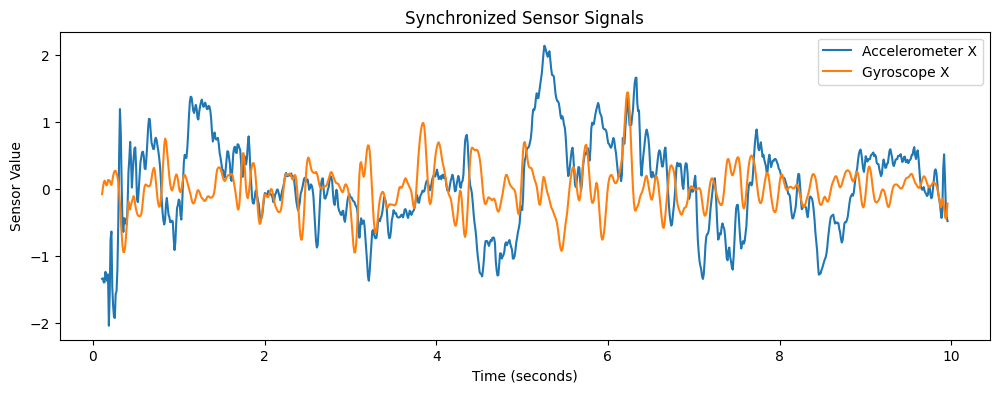

In [24]:
plt.figure(figsize=(12,4))

plt.plot(
    synchronized["seconds_elapsed"],
    synchronized["x_acc"],
    label="Accelerometer X"
)

plt.plot(
    synchronized["seconds_elapsed"],
    synchronized["x_gyro"],
    label="Gyroscope X"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Sensor Value")

plt.title("Synchronized Sensor Signals")

plt.legend()

plt.show()

# Windowing the Synchronized Sensor Data

The synchronized sensor data consists of continuous measurements collected over time. Rather than processing an entire recording as a single observation, the signal is divided into smaller overlapping windows.

Each window captures a short period of motion and serves as the basic unit for feature extraction. This approach increases the number of training samples while preserving the temporal nature of the activity.

In this project, a window duration of **1 second** with **50% overlap** is used. Since the average sampling rate is approximately 100 Hz, each window contains roughly 100 sensor measurements.

In [25]:
# Window parameters

window_duration = 1.0      # seconds
overlap = 0.5              # 50%

window_size = int(sampling_rate * window_duration)
step_size = int(window_size * (1 - overlap))

print(f"Sampling Rate : {sampling_rate:.2f} Hz")
print(f"Window Size   : {window_size} samples")
print(f"Step Size     : {step_size} samples")

Sampling Rate : 100.81 Hz
Window Size   : 100 samples
Step Size     : 50 samples


## Creating Sliding Windows for a Sample Recording

Before processing the entire dataset, the windowing procedure is tested on a single recording to verify that the windows are generated correctly.

In [26]:
sample = recordings[0]["synchronized"]

windows = []

In [27]:
for start in range(0, len(sample) - window_size + 1, step_size):

    end = start + window_size

    window = sample.iloc[start:end]

    windows.append(window)

In [28]:
print(f"Number of windows: {len(windows)}")

Number of windows: 19


In [29]:
windows[0].head()

,time_acc,seconds_elapsed,z_acc,y_acc,x_acc,time_gyro,z_gyro,y_gyro,x_gyro
0,1782829384360890600,0.085891,-0.037668,-0.086128,-0.168845,1782829384360890600,-0.000918,0.087821,0.040641
1,1782829384370819600,0.095820,0.039936,-0.132671,-0.036422,1782829384370819600,-0.001733,0.076716,0.046115
2,1782829384380748500,0.105749,0.170398,-0.190528,0.089976,1782829384380748500,0.029325,0.029240,0.032450
3,1782829384390677500,0.115677,0.241274,-0.247702,0.155522,1782829384390677500,0.083195,-0.033804,0.014346
4,1782829384400606700,0.125607,0.289934,-0.248699,0.196637,1782829384400606700,0.128297,-0.110936,0.018365


In [30]:
windows[0].shape

(100, 9)

## Visualizing a Sliding Window

The figure below shows one window extracted from the synchronized sensor signal. Each window contains approximately one second of sensor measurements and represents a single observation that will later be summarized into features.

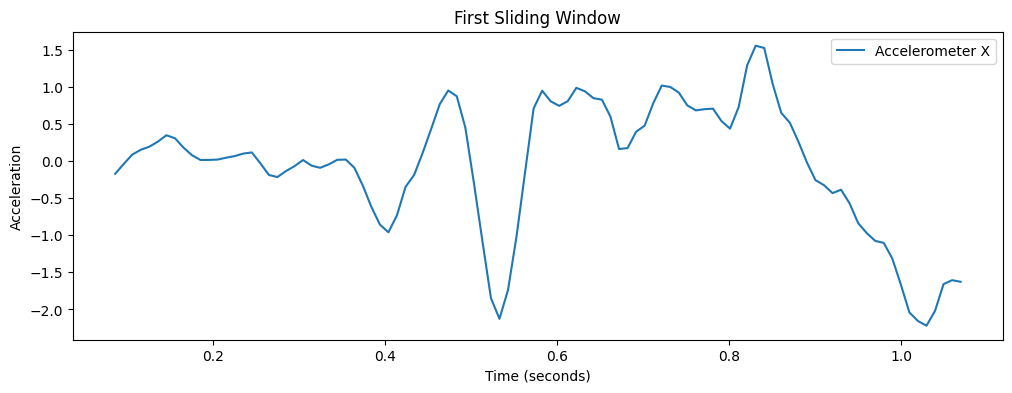

In [31]:
window = windows[0]

plt.figure(figsize=(12,4))

plt.plot(
    window["seconds_elapsed"],
    window["x_acc"],
    label="Accelerometer X"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration")

plt.title("First Sliding Window")

plt.legend()

plt.show()

## Applying Windowing to the Entire Dataset

After verifying the windowing procedure on a sample recording, the same process is applied to every synchronized recording.

The generated windows are stored together with each recording and will be used as the input for feature extraction.

In [32]:
for recording in recordings:

    signal = recording["synchronized"]

    windows = []

    for start in range(0, len(signal) - window_size + 1, step_size):

        end = start + window_size

        window = signal.iloc[start:end]

        windows.append(window)

    recording["windows"] = windows

In [33]:
#verify the results
for recording in recordings[:5]:

    print(
        f"{recording['recording']}: {len(recording['windows'])} windows"
    )

jumping1: 19 windows
jumping12: 17 windows
jumping2: 18 windows
jumping11: 17 windows
jumping3: 20 windows


In [34]:
print(recordings[0].keys())

dict_keys(['activity', 'recording', 'accelerometer', 'gyroscope', 'metadata', 'synchronized', 'windows'])


In [35]:
#windows summary
window_counts = [
    len(recording["windows"])
    for recording in recordings
]

print(f"Minimum windows : {min(window_counts)}")
print(f"Maximum windows : {max(window_counts)}")
print(f"Average windows : {np.mean(window_counts):.2f}")

Minimum windows : 17
Maximum windows : 21
Average windows : 18.48


# Time-Domain Feature Extraction

Time-domain features summarize the statistical characteristics of the sensor signals within each sliding window.

The extracted features include the mean, variance, standard deviation, root mean square (RMS), signal magnitude area (SMA), and correlation between sensor axes.

In [36]:
def extract_time_features(window):

    features = {}

    sensor_columns = [
        "x_acc",
        "y_acc",
        "z_acc",
        "x_gyro",
        "y_gyro",
        "z_gyro"
    ]

    for sensor in sensor_columns:

        signal = window[sensor]

        features[f"{sensor}_mean"] = signal.mean()
        features[f"{sensor}_variance"] = signal.var()
        features[f"{sensor}_std"] = signal.std()
        features[f"{sensor}_rms"] = np.sqrt(np.mean(signal ** 2))

    # Signal Magnitude Area (Accelerometer)
    features["acc_sma"] = (
        np.abs(window["x_acc"]) +
        np.abs(window["y_acc"]) +
        np.abs(window["z_acc"])
    ).mean()

    # Signal Magnitude Area (Gyroscope)
    features["gyro_sma"] = (
        np.abs(window["x_gyro"]) +
        np.abs(window["y_gyro"]) +
        np.abs(window["z_gyro"])
    ).mean()

    # Accelerometer Correlations
    features["corr_xy_acc"] = window["x_acc"].corr(window["y_acc"])
    features["corr_xz_acc"] = window["x_acc"].corr(window["z_acc"])
    features["corr_yz_acc"] = window["y_acc"].corr(window["z_acc"])

    # Gyroscope Correlations
    features["corr_xy_gyro"] = window["x_gyro"].corr(window["y_gyro"])
    features["corr_xz_gyro"] = window["x_gyro"].corr(window["z_gyro"])
    features["corr_yz_gyro"] = window["y_gyro"].corr(window["z_gyro"])

    return features

# Frequency-Domain Feature Extraction

The Fast Fourier Transform (FFT) converts each sensor signal from the time domain into the frequency domain.

The extracted frequency-domain features include the dominant frequency, spectral energy, and the first five FFT components for each sensor axis.

In [37]:
from scipy.fft import rfft

In [38]:
def extract_frequency_features(window):

    features = {}

    sensor_columns = [
        "x_acc",
        "y_acc",
        "z_acc",
        "x_gyro",
        "y_gyro",
        "z_gyro"
    ]

    for sensor in sensor_columns:

        signal = window[sensor] - window[sensor].mean()  # remove DC offset before FFT

        fft_values = np.abs(rfft(signal))

        frequencies = np.fft.rfftfreq(
            len(signal),
            d=1 / sampling_rate
        )

        dominant_index = np.argmax(fft_values[1:]) + 1  # skip the DC bin at index 0

        features[f"{sensor}_dominant_frequency"] = frequencies[dominant_index]

        features[f"{sensor}_spectral_energy"] = np.sum(fft_values ** 2)

        for i in range(5):

            features[f"{sensor}_fft_component_{i+1}"] = fft_values[i]

    return features

# Combining Time-Domain and Frequency-Domain Features

The time-domain and frequency-domain features are combined to form a single feature vector for each sliding window.

Each feature vector represents one observation that will later be used to train the Hidden Markov Model.

In [39]:
def extract_features(window):

    features = {}

    time_features = extract_time_features(window)
    frequency_features = extract_frequency_features(window)

    features.update(time_features)
    features.update(frequency_features)

    return features

In [40]:
#test on one window
first_window = recordings[0]["windows"][0]

features = extract_features(first_window)

pd.Series(features)

,0
x_acc_mean,-5.284331e-02
x_acc_variance,7.721649e-01
x_acc_std,8.787291e-01
x_acc_rms,8.759199e-01
y_acc_mean,3.883569e-01
...,...
z_gyro_fft_component_1,1.221245e-15
z_gyro_fft_component_2,8.093719e+00
z_gyro_fft_component_3,1.157383e+01
z_gyro_fft_component_4,7.278569e+00


## Test by extracting Features from One Recording

The feature extraction function is applied to every window in a recording. Each window produces one feature vector, resulting in one row per window.

In [41]:
feature_rows = []

for window in recordings[0]["windows"]:

    feature_rows.append(extract_features(window))

In [42]:
feature_df = pd.DataFrame(feature_rows)

In [43]:
feature_df["activity"] = recordings[0]["activity"]

In [44]:
feature_df.head()

,x_acc_mean,x_acc_variance,x_acc_std,x_acc_rms,y_acc_mean,y_acc_variance,y_acc_std,y_acc_rms,z_acc_mean,z_acc_variance,...,y_gyro_fft_component_4,y_gyro_fft_component_5,z_gyro_dominant_frequency,z_gyro_spectral_energy,z_gyro_fft_component_1,z_gyro_fft_component_2,z_gyro_fft_component_3,z_gyro_fft_component_4,z_gyro_fft_component_5,activity
0,-0.052843,0.772165,0.878729,0.875920,0.388357,2.273638,1.507859,1.549749,0.851707,29.537234,...,14.267844,9.708038,2.016291,381.468341,1.221245e-15,8.093719,11.573833,7.278569,4.986693,jumping
1,0.665471,1.552694,1.246071,1.407131,-0.005288,5.789536,2.406145,2.394090,0.150249,54.654561,...,35.263488,15.815645,3.024436,596.059518,1.443290e-15,4.898181,2.202029,14.888498,5.326792,jumping
2,1.022294,1.696190,1.302379,1.650550,-0.693886,6.197516,2.489481,2.572357,-2.095462,64.851042,...,41.786195,10.343429,9.073309,661.273567,3.330669e-16,7.178918,6.745717,10.526270,1.642172,jumping
3,0.340802,1.625628,1.275001,1.313590,-0.082946,5.030897,2.242966,2.233264,-0.515081,77.270514,...,12.055864,14.523369,1.008145,509.730592,1.665335e-16,11.232077,2.214471,6.059997,2.490258,jumping
4,0.022903,0.771589,0.878401,0.874298,0.385333,3.859457,1.964550,1.992321,2.323322,67.812390,...,12.463159,10.653191,3.024436,259.949656,1.165734e-15,2.315921,1.541748,8.002039,3.545904,jumping


## Extracting Features from All Recordings

After verifying the feature extraction process on a single recording, the same procedure is applied to every recording in the dataset.

The feature vectors extracted from each window are combined into a single dataset, with each row representing one window and its corresponding activity label.

In [45]:
all_feature_rows = []

In [46]:
for recording in recordings:

    activity = recording["activity"]
    rec_id = recording["recording"]

    for window in recording["windows"]:

        features = extract_features(window)

        features["activity"] = activity
        features["recording"] = rec_id

        all_feature_rows.append(features)

In [47]:
features_df = pd.DataFrame(all_feature_rows)

In [48]:
features_df.head()

,x_acc_mean,x_acc_variance,x_acc_std,x_acc_rms,y_acc_mean,y_acc_variance,y_acc_std,y_acc_rms,z_acc_mean,z_acc_variance,...,y_gyro_fft_component_5,z_gyro_dominant_frequency,z_gyro_spectral_energy,z_gyro_fft_component_1,z_gyro_fft_component_2,z_gyro_fft_component_3,z_gyro_fft_component_4,z_gyro_fft_component_5,activity,recording
0,-0.052843,0.772165,0.878729,0.875920,0.388357,2.273638,1.507859,1.549749,0.851707,29.537234,...,9.708038,2.016291,381.468341,1.221245e-15,8.093719,11.573833,7.278569,4.986693,jumping,jumping1
1,0.665471,1.552694,1.246071,1.407131,-0.005288,5.789536,2.406145,2.394090,0.150249,54.654561,...,15.815645,3.024436,596.059518,1.443290e-15,4.898181,2.202029,14.888498,5.326792,jumping,jumping1
2,1.022294,1.696190,1.302379,1.650550,-0.693886,6.197516,2.489481,2.572357,-2.095462,64.851042,...,10.343429,9.073309,661.273567,3.330669e-16,7.178918,6.745717,10.526270,1.642172,jumping,jumping1
3,0.340802,1.625628,1.275001,1.313590,-0.082946,5.030897,2.242966,2.233264,-0.515081,77.270514,...,14.523369,1.008145,509.730592,1.665335e-16,11.232077,2.214471,6.059997,2.490258,jumping,jumping1
4,0.022903,0.771589,0.878401,0.874298,0.385333,3.859457,1.964550,1.992321,2.323322,67.812390,...,10.653191,3.024436,259.949656,1.165734e-15,2.315921,1.541748,8.002039,3.545904,jumping,jumping1


In [49]:
features_df.shape

(924, 76)

In [50]:
features_df["activity"].value_counts()

,count
activity,
standing,241
still,239
walking,227
jumping,217


In [51]:
nan_counts = features_df.isnull().sum()
print(nan_counts[nan_counts > 0])

features_df[[c for c in features_df.columns if c not in ["activity","recording"]]] = \
    features_df[[c for c in features_df.columns if c not in ["activity","recording"]]].fillna(0)

print(f"\nRemaining NaNs after fill: {features_df.isnull().sum().sum()}")

Series([], dtype: int64)

Remaining NaNs after fill: 0


# Train/Test Split by Recording

To properly evaluate the model on unseen data, the split must happen at the
**recording level**, not the window level. Since windows overlap by 50%,
splitting individual windows would leak information from the same recording
into both the training and test sets.

At least two recordings per activity are reserved for testing.

In [52]:
np.random.seed(42)

activity_per_recording = features_df.groupby("recording")["activity"].first()

train_ids = []
test_ids = []

for activity, group in activity_per_recording.groupby(activity_per_recording):
    ids = list(group.index)
    np.random.shuffle(ids)

    n_test = max(2, round(len(ids) * 0.2))  # guarantees >= 2 test recordings per activity

    test_ids.extend(ids[:n_test])
    train_ids.extend(ids[n_test:])

print("Test recordings:", test_ids)
print(f"\nTrain recordings: {len(train_ids)}, Test recordings: {len(test_ids)}")

train_df = features_df[features_df["recording"].isin(train_ids)].reset_index(drop=True)
test_df  = features_df[features_df["recording"].isin(test_ids)].reset_index(drop=True)

feature_cols = [c for c in features_df.columns if c not in ["activity", "recording"]]

Test recordings: ['jumping8', 'jumping7', 'standing5', 'standing7', 'standing1', 'still9', 'still7', 'still3', 'walking7', 'walking10']

Train recordings: 40, Test recordings: 10


# Feature Scaling

Features are standardized (zero mean, unit variance) because the Gaussian
HMM's emission model is sensitive to feature scale — variance/RMS features
range in the tens, while correlation features are bounded to [-1, 1]. Without
scaling, the larger-magnitude features would dominate the likelihood.

The scaler is fit only on the training recordings and applied unchanged to
the test recordings, to avoid leaking test-set statistics into training.

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

# Building Sequences for the HMM

hmmlearn expects data as one concatenated array plus a lengths array
indicating where each individual recording's sequence starts and ends, so
that transitions are never learned across recordings.

In [54]:
def build_sequences(df):
    return df.groupby("recording", sort=False).size().tolist()

train_lengths = build_sequences(train_df)
test_lengths = build_sequences(test_df)

print(f"Train sequences: {len(train_lengths)}, total windows: {sum(train_lengths)}")
print(f"Test sequences: {len(test_lengths)}, total windows: {sum(test_lengths)}")

Train sequences: 40, total windows: 736
Test sequences: 10, total windows: 188


# Experiment 1: Baseline HMM Trained with Baum–Welch (4 States, Fixed Seed)

A 4-state Gaussian HMM is trained first, under the assumption that each
hidden state should correspond to exactly one of the four recorded
activities. This experiment tests whether that assumption holds.

In [55]:
!pip install hmmlearn
from hmmlearn.hmm import GaussianHMM

model_exp1 = GaussianHMM(
    n_components=4,
    covariance_type="diag",
    n_iter=200,
    tol=1e-4,
    random_state=42,
    verbose=True
)
model_exp1.fit(X_train, train_lengths)

print(f"\nConverged: {model_exp1.monitor_.converged}")
print(f"Final log-likelihood: {model_exp1.monitor_.history[-1]:.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.2 MB/s eta 0:00:00


         1  -62396.26039166             +nan
         2   15731.80876185  +78128.06915352
         3   21761.81882215   +6030.01006030
         4   22654.27918016    +892.46035801
         5   22660.16642170      +5.88724154
         6   22664.72347400      +4.55705230
         7   22670.26931289      +5.54583889
         8   22677.30762403      +7.03831114



Converged: True
Final log-likelihood: 22682.17


         9   22680.43894136      +3.13131733
        10   22681.49035178      +1.05141043
        11   22681.86479826      +0.37444648
        12   22682.07955566      +0.21475740
        13   22682.15035536      +0.07079971
        14   22682.16628316      +0.01592780
        15   22682.17000726      +0.00372410
        16   22682.17096617      +0.00095891
        17   22682.17122049      +0.00025432
        18   22682.17128823      +0.00006774


# Decoding with Viterbi and Mapping Hidden States to Activities

The Viterbi algorithm decodes the most likely hidden state sequence for the
training data. Since the HMM's states are unlabeled (0-3), each state is
mapped to the activity it most frequently corresponds to, using the known
training labels.

In [56]:
hidden_states_train_exp1 = model_exp1.predict(X_train, train_lengths)

state_to_activity_exp1 = {}
for state in range(model_exp1.n_components):
    mask = hidden_states_train_exp1 == state
    if mask.sum() > 0:
        state_to_activity_exp1[state] = train_df.loc[mask, "activity"].mode()[0]
    else:
        state_to_activity_exp1[state] = "unassigned"

print(state_to_activity_exp1)

{0: 'jumping', 1: 'still', 2: 'walking', 3: 'jumping'}


# Evaluating on Unseen Data

In [57]:
from sklearn.metrics import confusion_matrix, classification_report

hidden_states_test_exp1 = model_exp1.predict(X_test, test_lengths)
predicted_activity_exp1 = [state_to_activity_exp1[s] for s in hidden_states_test_exp1]
true_activity = test_df["activity"].tolist()

labels = sorted(train_df["activity"].unique())

print(classification_report(true_activity, predicted_activity_exp1, labels=labels))

cm_exp1 = confusion_matrix(true_activity, predicted_activity_exp1, labels=labels)
cm_df_exp1 = pd.DataFrame(cm_exp1, index=labels, columns=labels)
print(cm_df_exp1)

              precision    recall  f1-score   support

     jumping       1.00      1.00      1.00        36
    standing       0.00      0.00      0.00        59
       still       0.48      1.00      0.65        55
     walking       1.00      1.00      1.00        38

    accuracy                           0.69       188
   macro avg       0.62      0.75      0.66       188
weighted avg       0.53      0.69      0.58       188

          jumping  standing  still  walking
jumping        36         0      0        0
standing        0         0     59        0
still           0         0     55        0
walking         0         0      0       38


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
results_exp1 = []
for i, activity in enumerate(labels):
    tp = cm_exp1[i, i]
    fn = cm_exp1[i, :].sum() - tp
    fp = cm_exp1[:, i].sum() - tp
    tn = cm_exp1.sum() - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results_exp1.append({
        "Activity": activity,
        "Number of Samples": cm_exp1[i, :].sum(),
        "Sensitivity": round(sensitivity, 3),
        "Specificity": round(specificity, 3)
    })

overall_accuracy_exp1 = cm_exp1.trace() / cm_exp1.sum()
results_df_exp1 = pd.DataFrame(results_exp1)
results_df_exp1["Overall Accuracy"] = round(overall_accuracy_exp1, 3)
results_df_exp1

,Activity,Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,jumping,36,1.0,1.000,0.686
1,standing,59,0.0,1.000,0.686
2,still,55,1.0,0.556,0.686
3,walking,38,1.0,1.000,0.686


# Visualizations

Transition matrix, emission characteristics, confusion matrix, and a decoded
sequence plot for one held-out recording.

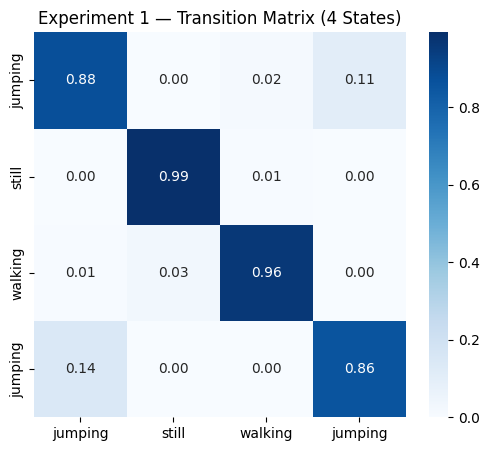

In [59]:
import seaborn as sns

state_labels_exp1 = [state_to_activity_exp1[s] for s in range(model_exp1.n_components)]

plt.figure(figsize=(6,5))
sns.heatmap(model_exp1.transmat_, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=state_labels_exp1, yticklabels=state_labels_exp1)
plt.title("Experiment 1 — Transition Matrix (4 States)")
plt.show()

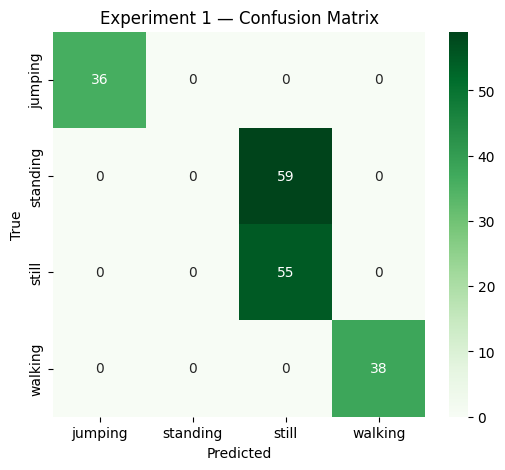

In [60]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_df_exp1, annot=True, fmt="d", cmap="Greens")
plt.title("Experiment 1 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

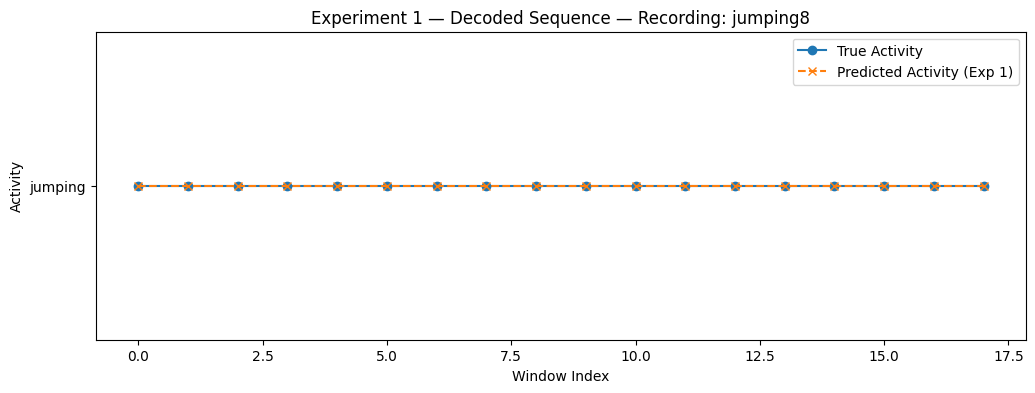

In [61]:
example_recording_exp1 = test_ids[0]
example_mask_exp1 = test_df["recording"] == example_recording_exp1

example_true_exp1 = test_df.loc[example_mask_exp1, "activity"].values
example_pred_states_exp1 = hidden_states_test_exp1[example_mask_exp1.values]
example_pred_exp1 = [state_to_activity_exp1[s] for s in example_pred_states_exp1]

plt.figure(figsize=(12,4))
plt.plot(example_true_exp1, label="True Activity", marker="o")
plt.plot(example_pred_exp1, label="Predicted Activity (Exp 1)", marker="x", linestyle="--")
plt.title(f"Experiment 1 — Decoded Sequence — Recording: {example_recording_exp1}")
plt.xlabel("Window Index")
plt.ylabel("Activity")
plt.legend()
plt.xticks(rotation=0)
plt.show()

# Diagnosing the Standing vs. Still Confusion. Why Did Experiment 1 Fail on Standing?

Experiment 1's confusion matrix shows every "standing" test window
misclassified as "still," with two of the four hidden states both mapping
to "jumping." Before changing the model, the raw features are checked to
confirm whether standing and still are actually separable in the data.

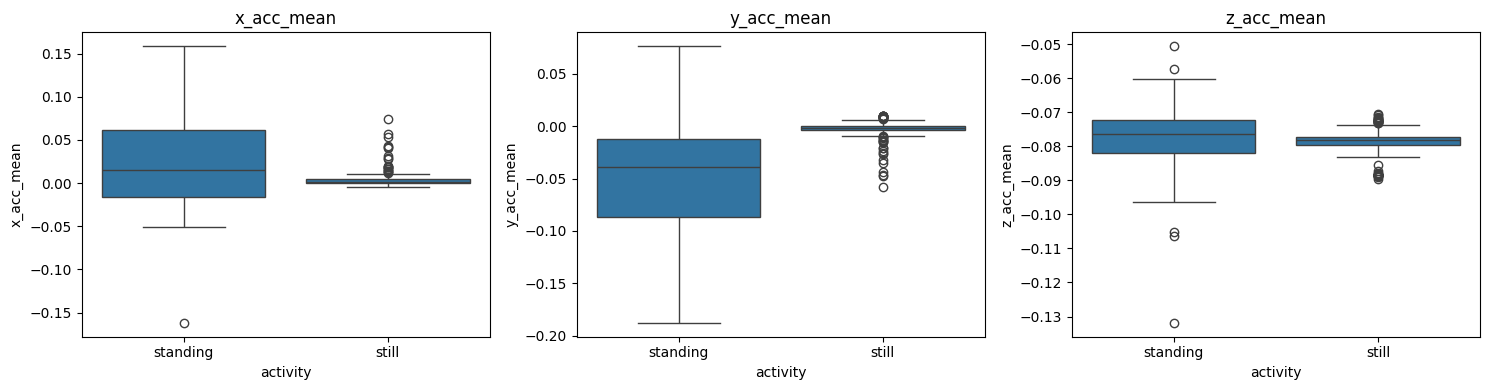

In [62]:
import seaborn as sns

compare_df = features_df[features_df["activity"].isin(["standing", "still"])]

orientation_features = ["x_acc_mean", "y_acc_mean", "z_acc_mean"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, orientation_features):
    sns.boxplot(data=compare_df, x="activity", y=feature, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

# Experiment 2: Searching Over State Count and Initialization

The diagnostic above confirms standing and still are separable on
`x_acc_mean` / `y_acc_mean`, meaning Experiment 1's failure was a model
configuration issue, not a data issue. This experiment searches across
different numbers of hidden states and random initializations to find a
configuration where all four activities are represented by at least one
state.

In [63]:
from hmmlearn.hmm import GaussianHMM

results_search = []

for n_states in [4, 5, 6]:
    for seed in [0, 1, 7, 42, 99]:

        trial_model = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=200,
            tol=1e-4,
            random_state=seed
        )
        trial_model.fit(X_train, train_lengths)

        trial_hidden_train = trial_model.predict(X_train, train_lengths)

        trial_state_to_activity = {}
        for state in range(n_states):
            mask = trial_hidden_train == state
            if mask.sum() > 0:
                trial_state_to_activity[state] = train_df.loc[mask, "activity"].mode()[0]

        activities_covered = len(set(trial_state_to_activity.values()))

        trial_hidden_test = trial_model.predict(X_test, test_lengths)
        trial_predicted = [trial_state_to_activity.get(s, "unassigned") for s in trial_hidden_test]
        trial_true = test_df["activity"].tolist()

        accuracy = sum(p == t for p, t in zip(trial_predicted, trial_true)) / len(trial_true)

        results_search.append({
            "n_states": n_states,
            "seed": seed,
            "log_likelihood": trial_model.score(X_train, train_lengths),
            "activities_covered": activities_covered,
            "accuracy": round(accuracy, 3)
        })

results_search_df = pd.DataFrame(results_search).sort_values(
    ["activities_covered", "accuracy"], ascending=[False, False]
)

results_search_df

,n_states,seed,log_likelihood,activities_covered,accuracy
10,6,0,41102.432573,4,0.984
11,6,1,40996.570721,4,0.984
12,6,7,41102.432530,4,0.984
13,6,42,41239.556867,4,0.984
14,6,99,41097.019889,4,0.984
0,4,0,22680.917625,3,0.686
1,4,1,22796.936926,3,0.686
2,4,7,22680.917626,3,0.686
3,4,42,22682.171306,3,0.686
4,4,99,22680.917604,3,0.686


In [64]:
best_row = results_search_df.iloc[0]
best_n_states = int(best_row["n_states"])
best_seed = int(best_row["seed"])

print(f"Best configuration: n_states={best_n_states}, seed={best_seed}")

model_exp2 = GaussianHMM(
    n_components=best_n_states,
    covariance_type="diag",
    n_iter=200,
    tol=1e-4,
    random_state=best_seed,
    verbose=True
)
model_exp2.fit(X_train, train_lengths)

print(f"\nConverged: {model_exp2.monitor_.converged}")
print(f"Final log-likelihood: {model_exp2.monitor_.history[-1]:.2f}")

Best configuration: n_states=6, seed=0


         1  -63922.66356815             +nan
         2   19714.14155966  +83636.80512782
         3   35231.42019864  +15517.27863898
         4   39475.13361749   +4243.71341885
         5   40923.68024608   +1448.54662859
         6   41085.58423164    +161.90398555
         7   41090.39692873      +4.81269709
         8   41091.07763978      +0.68071105
         9   41093.85124123      +2.77360145
        10   41095.14226881      +1.29102759
        11   41095.55523127      +0.41296246
        12   41097.40731557      +1.85208430
        13   41101.46659853      +4.05928296
        14   41101.70167834      +0.23507982
        15   41101.71410971      +0.01243137
        16   41101.72326041      +0.00915070
        17   41101.73514076      +0.01188035
        18   41101.75662855      +0.02148780
        19   41101.80667246      +0.05004391
        20   41101.94029901      +0.13362655
        21   41102.21579933      +0.27550032
        22   41102.41089036      +0.19509104
        23


Converged: True
Final log-likelihood: 41102.43


## Decode and Map States to Activities — Experiment 2

Since the HMM's states are unlabeled, each state is mapped to the activity
it most frequently corresponds to, using the known training labels — the
same procedure applied in Experiment 1, now repeated for the retrained model.

In [65]:
hidden_states_train_exp2 = model_exp2.predict(X_train, train_lengths)

state_to_activity_exp2 = {}
for state in range(model_exp2.n_components):
    mask = hidden_states_train_exp2 == state
    if mask.sum() > 0:
        state_to_activity_exp2[state] = train_df.loc[mask, "activity"].mode()[0]
    else:
        state_to_activity_exp2[state] = "unassigned"

print(state_to_activity_exp2)

{0: 'jumping', 1: 'walking', 2: 'still', 3: 'standing', 4: 'jumping', 5: 'jumping'}


In [66]:
#State sample sizes (sanity check)
unique_exp2, counts_exp2 = np.unique(hidden_states_train_exp2, return_counts=True)
for state, count in zip(unique_exp2, counts_exp2):
    print(f"State {state} ({state_to_activity_exp2[state]}): {count} training windows")

State 0 (jumping): 55 training windows
State 1 (walking): 194 training windows
State 2 (still): 183 training windows
State 3 (standing): 176 training windows
State 4 (jumping): 97 training windows
State 5 (jumping): 31 training windows


### Evaluating on Unseen Data — Experiment 2

The retrained model is decoded on the held-out test recordings using
Viterbi, and predictions are compared against the true activity labels —
mirroring the Experiment 1 evaluation exactly, so the two are directly
comparable.

In [67]:
hidden_states_test_exp2 = model_exp2.predict(X_test, test_lengths)
predicted_activity_exp2 = [state_to_activity_exp2[s] for s in hidden_states_test_exp2]
true_activity = test_df["activity"].tolist()

labels = sorted(train_df["activity"].unique())

print(classification_report(true_activity, predicted_activity_exp2, labels=labels))

cm_exp2 = confusion_matrix(true_activity, predicted_activity_exp2, labels=labels)
cm_df_exp2 = pd.DataFrame(cm_exp2, index=labels, columns=labels)
print(cm_df_exp2)

              precision    recall  f1-score   support

     jumping       1.00      1.00      1.00        36
    standing       0.95      1.00      0.98        59
       still       1.00      0.95      0.97        55
     walking       1.00      1.00      1.00        38

    accuracy                           0.98       188
   macro avg       0.99      0.99      0.99       188
weighted avg       0.98      0.98      0.98       188

          jumping  standing  still  walking
jumping        36         0      0        0
standing        0        59      0        0
still           0         3     52        0
walking         0         0      0       38


## Sensitivity and Specificity Table — Experiment 2

Per-activity sensitivity, specificity, and overall accuracy are computed
from the Experiment 2 confusion matrix, using the same method as Experiment 1.

In [68]:
results_exp2 = []

for i, activity in enumerate(labels):
    tp = cm_exp2[i, i]
    fn = cm_exp2[i, :].sum() - tp
    fp = cm_exp2[:, i].sum() - tp
    tn = cm_exp2.sum() - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    n_samples = cm_exp2[i, :].sum()

    results_exp2.append({
        "Activity": activity,
        "Number of Samples": n_samples,
        "Sensitivity": round(sensitivity, 3),
        "Specificity": round(specificity, 3)
    })

overall_accuracy_exp2 = cm_exp2.trace() / cm_exp2.sum()

results_df_exp2 = pd.DataFrame(results_exp2)
results_df_exp2["Overall Accuracy"] = round(overall_accuracy_exp2, 3)
results_df_exp2

,Activity,Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,jumping,36,1.000,1.000,0.984
1,standing,59,1.000,0.977,0.984
2,still,55,0.945,1.000,0.984
3,walking,38,1.000,1.000,0.984


# Visualizations — Experiment 2

Transition matrix, confusion matrix, and a decoded sequence plot for the
retrained model, for direct visual comparison against Experiment 1's
equivalents above.

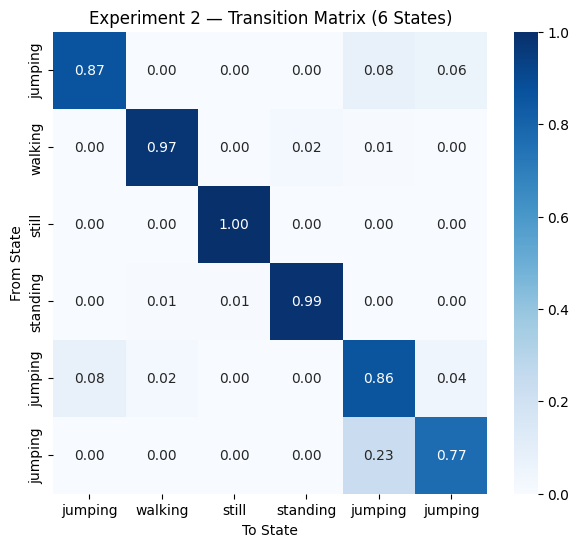

In [69]:
state_labels_exp2 = [state_to_activity_exp2[s] for s in range(model_exp2.n_components)]

plt.figure(figsize=(7,6))
sns.heatmap(model_exp2.transmat_, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=state_labels_exp2, yticklabels=state_labels_exp2)
plt.title(f"Experiment 2 — Transition Matrix ({best_n_states} States)")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

# Emission Probabilities — Experiment 2

The transition matrix (A) shows how the model moves between hidden states. The
emission model (B) is the other half of the HMM: it describes what each hidden
state's Gaussian distribution looks like across the features. Since covariance_type
is "diag", the mean vector `model_exp2.means_` fully describes each state's
expected feature values. Plotting the per-axis mean features (already in standardized
units) as a heatmap makes it possible to see, at a glance, which features each state
'lit up' on — for example, the states mapped to jumping should show high means on
the variance/RMS features, while still should sit close to zero everywhere.

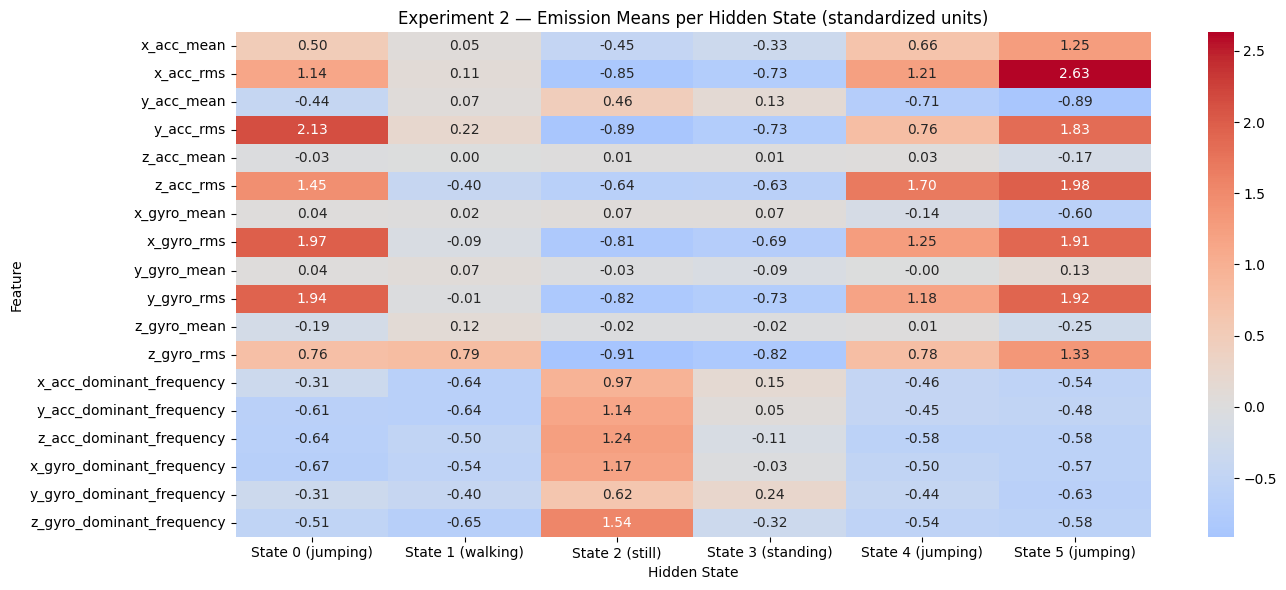

In [70]:
emission_features = [
    c for c in feature_cols
    if c.endswith("_mean") or c.endswith("_rms") or c.endswith("_dominant_frequency")
]
emission_idx = [feature_cols.index(c) for c in emission_features]

emission_means = pd.DataFrame(
    model_exp2.means_[:, emission_idx],
    columns=emission_features,
    index=[f"State {s} ({state_labels_exp2[s]})" for s in range(model_exp2.n_components)]
)

plt.figure(figsize=(14, 6))
sns.heatmap(emission_means.T, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Experiment 2 — Emission Means per Hidden State (standardized units)")
plt.xlabel("Hidden State")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

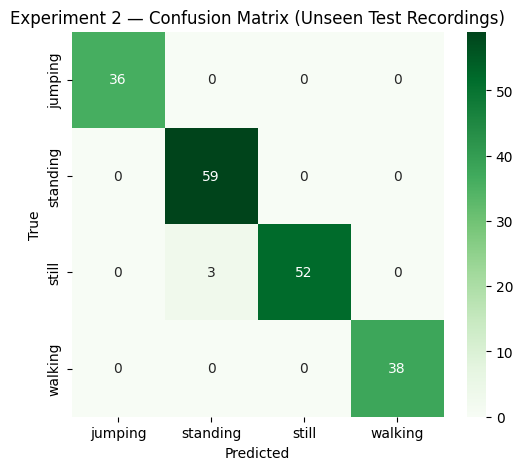

In [71]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_df_exp2, annot=True, fmt="d", cmap="Greens")
plt.title("Experiment 2 — Confusion Matrix (Unseen Test Recordings)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

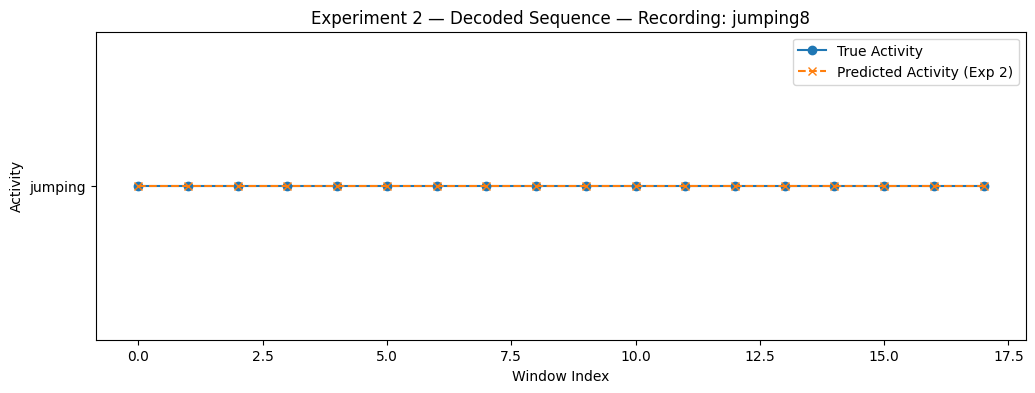

In [72]:
example_recording_exp2 = test_ids[0]
example_mask_exp2 = test_df["recording"] == example_recording_exp2

example_true_exp2 = test_df.loc[example_mask_exp2, "activity"].values
example_pred_states_exp2 = hidden_states_test_exp2[example_mask_exp2.values]
example_pred_exp2 = [state_to_activity_exp2[s] for s in example_pred_states_exp2]

plt.figure(figsize=(12,4))
plt.plot(example_true_exp2, label="True Activity", marker="o")
plt.plot(example_pred_exp2, label="Predicted Activity (Exp 2)", marker="x", linestyle="--")
plt.title(f"Experiment 2 — Decoded Sequence — Recording: {example_recording_exp2}")
plt.xlabel("Window Index")
plt.ylabel("Activity")
plt.legend()
plt.xticks(rotation=0)
plt.show()

# Comparing Experiment 1 vs Experiment 2

In [73]:
comparison_df = pd.DataFrame({
    "Activity": labels,
    "Exp1 Sensitivity": results_df_exp1["Sensitivity"].values,
    "Exp2 Sensitivity": results_df_exp2["Sensitivity"].values,
    "Exp1 Specificity": results_df_exp1["Specificity"].values,
    "Exp2 Specificity": results_df_exp2["Specificity"].values,
})
comparison_df["Exp1 Overall Accuracy"] = round(overall_accuracy_exp1, 3)
comparison_df["Exp2 Overall Accuracy"] = round(overall_accuracy_exp2, 3)

comparison_df

,Activity,Exp1 Sensitivity,Exp2 Sensitivity,Exp1 Specificity,Exp2 Specificity,Exp1 Overall Accuracy,Exp2 Overall Accuracy
0,jumping,1.0,1.000,1.000,1.000,0.686,0.984
1,standing,0.0,1.000,1.000,0.977,0.686,0.984
2,still,1.0,0.945,0.556,1.000,0.686,0.984
3,walking,1.0,1.000,1.000,1.000,0.686,0.984
